In [1]:
import sys
import os
import numpy as np

sys.path.append(os.path.abspath('..'))

from src.config import SolverConfig
from src.models.spacecraft import Spacecraft
from src.models.body import Body
from src.optimizer import Optimizer
from src.utils import cart2eq, cart2kep

from scripts.ephemerides import load_states

earth_path = "../src/horizons_results_earth_heliocentric_state_vector.txt"
mars_path = "../src/horizons_results_mars_heliocentric_state_vector.txt"

earth_loc, earth_dt = load_states(earth_path)
mars_loc, mars_dt = load_states(mars_path)

earth_loc = earth_loc*1e3
mars_loc = mars_loc*1e3

cfg = SolverConfig()
Earth = Body(name="earth",mu=3.986e14)
Mars = Body(name="mars",mu=4.283e13)
Sun = Body(name="sun",mu=1.327e20)

In [ ]:
new_y0 = np.array([6e7, 0, 0, 0, -5.65e2,9.8e2])

tf_days = np.linspace(500,500,1, dtype=int)

target_orbit = [3.352e7, 0.802, 1e-12, 1.06, 1e-12, 0]

Mars = Body(name="mars",mu=4.283e13)

for tf in tf_days:
    print("testing transfer time", tf)
    Psyche = Spacecraft()
    Psyche.m0 = 4000
    r0v0 = new_y0
    y0 = np.hstack((r0v0, 4000))

    print(cart2eq(r0v0, Mars.mu))
    print(target_orbit)
    fw_opt = Optimizer(cfg, Psyche, target_orbit=target_orbit)
    fw_opt.propagator.body = Mars
    fw_opt.controller.gains.nominal_throttle = 0.1
    fw_opt.controller.gains.W_oe = np.array([5.0,1.0,1.0,0.1,0.1,0])
    fw_ts, fw_sol, fw_as, fw_es, fw_thist, fw_uhist, fw_qhist = fw_opt.simulate_forward(0, tf*86400, y0, mars_loc)

    # Extract final mass from solution (adjust index for your sol format)
    final_mass = fw_sol[6, -1]  # Assuming [r,v,m] format, m at index 6
    mee_error = np.array(cart2eq(fw_sol[0:6,-1],Mars.mu)) - np.array(fw_opt.true_target)
    print(mee_error)
    
        

testing transfer time 500
[np.float64(289310441.88010126), np.float64(0.7926103198692505), np.float64(0.0), np.float64(1.7308215404148621), np.float64(0.0), np.float64(0.0)]
[33520000.0, 0.802, 1e-12, 1.06, 1e-12, 0]


<lambdifygenerated-1>:9: RuntimeWarning: invalid value encountered in sqrt
  x3 = sqrt(x2/mu)
<lambdifygenerated-1>:20: RuntimeWarning: invalid value encountered in sqrt
  x14 = 2.0*a**2*x13*(2*a - 2*a_T)/sqrt(mu*x2)
<lambdifygenerated-2>:14: RuntimeWarning: invalid value encountered in sqrt
  x8 = sqrt(x7/mu)
<lambdifygenerated-2>:30: RuntimeWarning: invalid value encountered in sqrt
  x24 = 2.0*a**2*x0*(2*a - 2*a_T)/sqrt(mu*x7)


[-1.44125071e+06 -7.89876305e-02 -2.22870916e-02 -1.33313031e-01
 -2.17337590e-01 -2.63288494e+00]


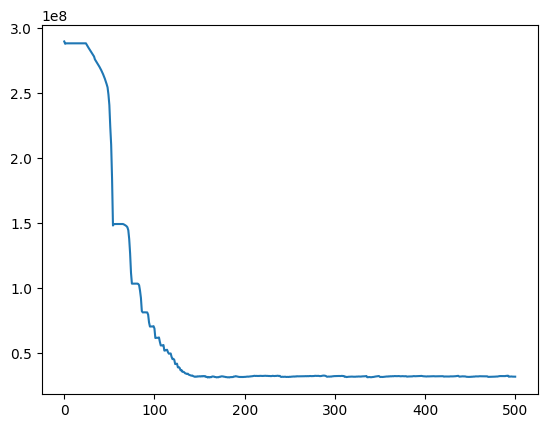

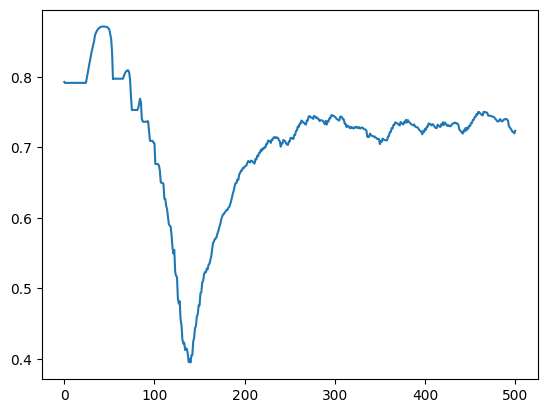

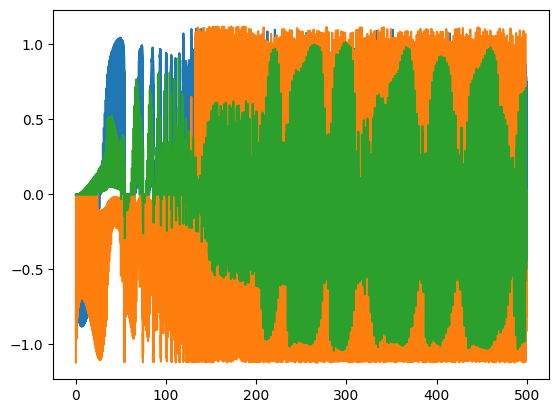

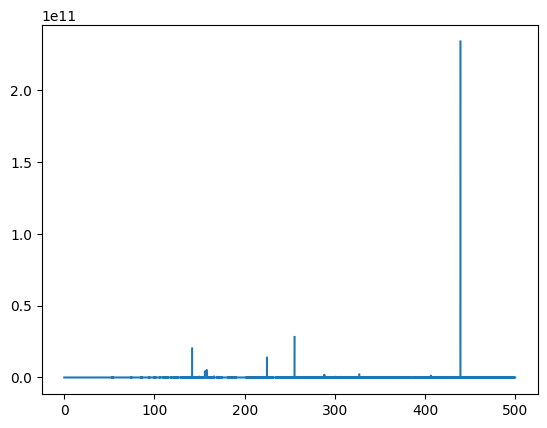

In [6]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fw_as)
plt.show()

plt.figure()
plt.plot(fw_es)
plt.show()

plt.figure()
plt.plot(fw_thist/86400, fw_uhist)
plt.show()

plt.figure()
plt.plot(fw_thist/86400, fw_qhist)
plt.show()

In [4]:
print(fw_opt.controller.phase)

1


In [7]:
best_departure = 0
best_tf = tf
best_sol = fw_sol.copy()
best_fw_ts = fw_ts.copy()

import plotly.graph_objects as go
import numpy as np


# Convert to Gm (1e9 m)
AU_TO_GM = 1.495978707e2

# Example: pick one TOF from your loop
best_tf = tf_days[-1]  # or pick the one you want to visualize
best_t0 = best_departure



# Forward trajectory (Earth -> Mars)
t_days_fw = fw_ts / 86400
r_traj_fw = fw_sol[0:3, :].T / 1e9

# Create 3D figure
fig = go.Figure()


# 1. Forward arc (Earth → Mars)
fig.add_trace(go.Scatter3d(
    x=r_traj_fw[:, 0], y=r_traj_fw[:, 1], z=r_traj_fw[:, 2],
    mode='lines',
    name='Forward Q‑law arc (Earth → Mars)',
    line=dict(width=6, color='cyan'),
    hovertemplate='<b>Time: %{text:.1f} days</b><br>X: %{x:.2f} Gm<br>Y: %{y:.2f} Gm<br>Z: %{z:.2f} Gm<extra></extra>',
    text=t_days_fw
))
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers',
    name='Sun',
    marker=dict(size=15, color='yellow', symbol='circle', line=dict(color='orange', width=2))
))
fig.update_layout(
    scene=dict(
        aspectmode='data'
    )
)